In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy import stats 


In [2]:
df = pd.read_csv("ncit_students.csv")

In [4]:
print(df.shape)
print(df.head(20))

(80, 8)
   StudentID  Gender      Faculty  StudyHours  Attendance  InternetHours  \
0       S100  Female     Computer         4.9        76.4            5.1   
1       S101  Female  Electronics         6.2        87.9            3.9   
2       S102  Female     Software         5.7        83.0            4.7   
3       S103    Male  Electronics         5.5        88.1            2.3   
4       S104    Male        Civil         6.4        75.6            2.0   
5       S105    Male     Software         5.4        78.3            5.3   
6       S106    Male     Software         4.1        68.6            4.7   
7       S107    Male     Computer         4.5        76.8            4.0   
8       S108    Male     Computer         4.2        85.9            5.9   
9       S109    Male     Software         5.3        77.0            2.6   
10      S110    Male  Electronics         3.4        84.8            3.4   
11      S111    Male  Electronics         2.3        74.3            5.5   
12  

# Part A – Correlation Between Numerical Variables Pearson, Spearman and Kendall

In [13]:
r, p1 = stats.pearsonr(df["StudyHours"], df["ExamScore"])
rho, p2 = stats.spearmanr(df["StudyHours"], df["ExamScore"])
tau, p3 = stats.kendalltau(df["StudyHours"], df["ExamScore"])

print("Pearson :", r, p1)
print("Spearman:", rho, p2)
print("Kendall :", tau, p3)

Pearson : 0.5117281426529917 1.2262298395404252e-06
Spearman: 0.4656450295488052 1.3462316702795483e-05
Kendall : 0.3248832890147874 2.3188561284004547e-05


## Attendance and Internet Hours Correlation

In [14]:
for col in ["Attendance", "InternetHours"]:
    rr, pp = stats.pearsonr(df[col], df["ExamScore"])

    print(f"{col}")
    print("Correlation =", round(rr,3))
    print("P-value =", round(pp,4))
    print()

Attendance
Correlation = 0.324
P-value = 0.0034

InternetHours
Correlation = -0.373
P-value = 0.0006



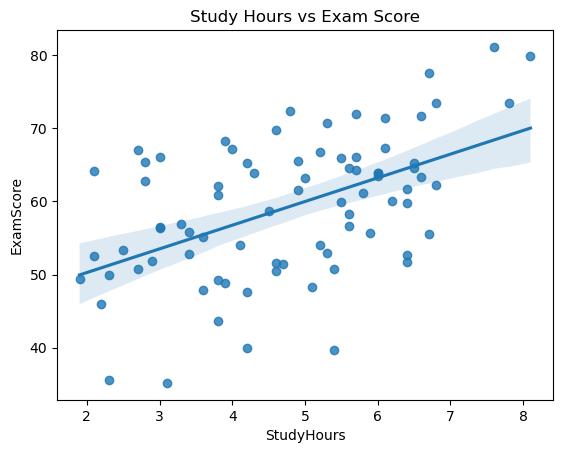

In [15]:
sns.regplot(
    x="StudyHours",
    y="ExamScore",
    data=df
)

plt.title("Study Hours vs Exam Score")
plt.show()

In [36]:
plt.savefig("Study Hours vs Exam Score", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Correlation Matrix and Heatmap

In [16]:
num = [
    "StudyHours",
    "Attendance",
    "InternetHours",
    "ExamScore"
]

corr_matrix = df[num].corr()

print(corr_matrix.round(3))

               StudyHours  Attendance  InternetHours  ExamScore
StudyHours          1.000       0.116         -0.119      0.512
Attendance          0.116       1.000         -0.014      0.324
InternetHours      -0.119      -0.014          1.000     -0.373
ExamScore           0.512       0.324         -0.373      1.000


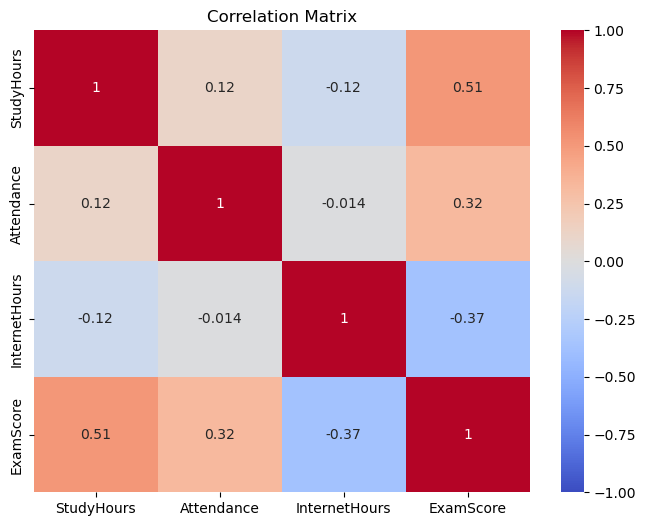

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()

In [37]:
plt.savefig("Correlation Matrix", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Part B – Numerical vs Categorical
# Point-Biserial Correlation (Gender vs ExamScore)

In [18]:
df["Gender_bin"] = (
    df["Gender"] == "Female"
).astype(int)

In [19]:
r_pb, p = stats.pointbiserialr(
    df["Gender_bin"],
    df["ExamScore"]
)

print("Point-Biserial Correlation =", round(r_pb,3))
print("P-value =", round(p,4))

Point-Biserial Correlation = -0.219
P-value = 0.0513


In [20]:
print(
    df.groupby("Gender")["ExamScore"]
    .agg(["count","mean","std"])
    .round(2)
)

        count   mean    std
Gender                     
Female     36  56.93  10.40
Male       44  61.12   8.56


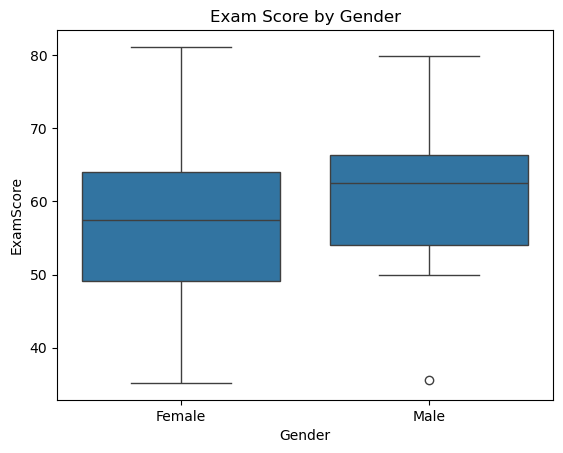

In [21]:
sns.boxplot(
    x="Gender",
    y="ExamScore",
    data=df
)

plt.title("Exam Score by Gender")
plt.show()

In [38]:
plt.savefig("Exam Score by Gender", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Correlation Ratio (Eta)

In [22]:
def correlation_ratio(categories, values):

    cats = pd.Categorical(categories)

    mean = values.mean()

    ss_total = ((values - mean)**2).sum()

    ss_between = sum(
        (
            (values[cats == c].mean() - mean)**2
        ) * (cats == c).sum()

        for c in cats.categories
    )

    eta = np.sqrt(ss_between / ss_total)

    return eta

In [23]:
eta = correlation_ratio(
    df["Faculty"],
    df["ExamScore"]
)

print("Eta =", round(eta,3))
print("Eta² =", round(eta**2,3))

Eta = 0.511
Eta² = 0.261


In [24]:
print(
    df.groupby("Faculty")["ExamScore"]
    .agg(["count","mean","std"])
    .round(2)
)

             count   mean   std
Faculty                        
Civil            9  49.36  6.01
Computer        24  64.29  7.09
Electronics     17  54.73  8.91
Software        30  60.71  9.58


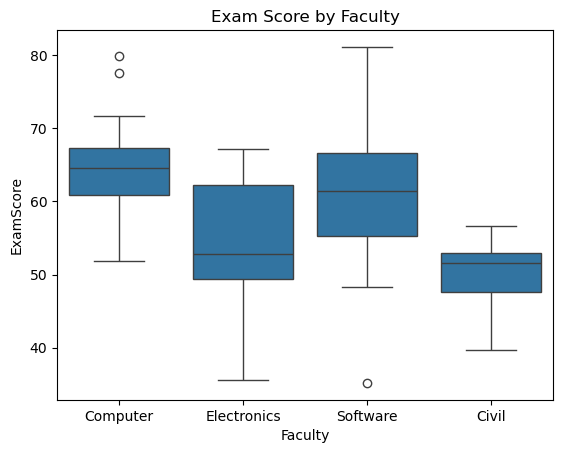

In [25]:
sns.boxplot(
    x="Faculty",
    y="ExamScore",
    data=df
)

plt.title("Exam Score by Faculty")
plt.show()

In [39]:
plt.savefig("SExam Score by Faculty", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Part C – Categorical vs Categorical

Faculty vs Result

In [26]:
ct = pd.crosstab(
    df["Faculty"],
    df["Result"]
)

print(ct)

Result       Fail  Pass
Faculty                
Civil           4     5
Computer        0    24
Electronics     6    11
Software        3    27


In [27]:
chi2, p, dof, expected = stats.chi2_contingency(ct)

print("Chi-square =", round(chi2,3))
print("DOF =", dof)
print("P-value =", round(p,4))

Chi-square = 15.305
DOF = 3
P-value = 0.0016


In [28]:
def cramers_v(conf):

    chi2 = stats.chi2_contingency(conf)[0]

    n = conf.values.sum()

    r, k = conf.shape

    return np.sqrt(
        chi2 / (n * (min(r,k)-1))
    )

In [29]:
cv = cramers_v(ct)

print("Cramer's V =", round(cv,3))

Cramer's V = 0.437


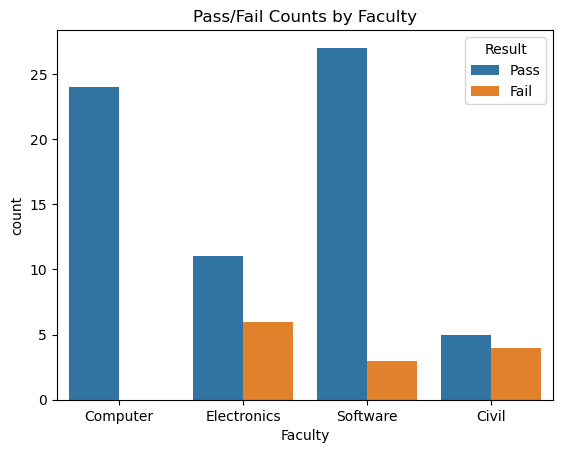

In [35]:
sns.countplot(
    data=df,
    x="Faculty",
    hue="Result"
)

plt.title("Pass/Fail Counts by Faculty")
plt.show()

In [42]:
plt.savefig("Pass_Fail Counts by Faculty", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

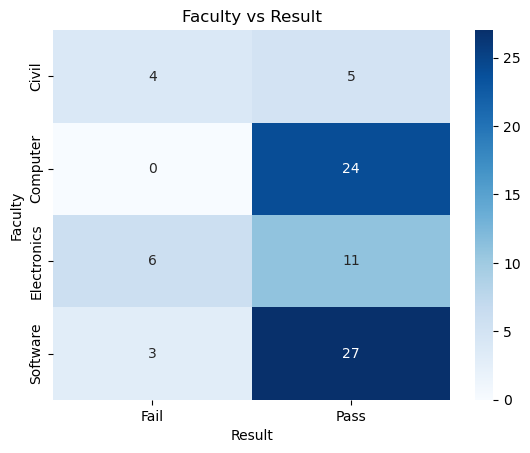

In [30]:
sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Faculty vs Result")
plt.show()

In [43]:
plt.savefig("Faculty vs Result", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Part D – Hypothesis Testing
1. One-Sample t-Test

H₀: Mean ExamScore = 50

In [31]:
t, p = stats.ttest_1samp(
    df["ExamScore"],
    50
)

print("Mean =", round(df["ExamScore"].mean(),2))
print("t =", round(t,3))
print("p =", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Mean = 59.24
t = 8.603
p = 5.792134147667904e-13
Reject H0


2. Two-Sample t-Test

Female vs Male

In [32]:
female = df[
    df["Gender"]=="Female"
]["ExamScore"]

male = df[
    df["Gender"]=="Male"
]["ExamScore"]

t, p = stats.ttest_ind(
    female,
    male,
    equal_var=False
)

print("t =", round(t,3))
print("p =", round(p,4))

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

t = -1.942
p = 0.0564
Fail to Reject H0


3. One-Way ANOVA


In [33]:
groups = [
    g["ExamScore"].values
    for _, g in df.groupby("Faculty")
]

F, p = stats.f_oneway(*groups)

print("F =", round(F,3))
print("p =", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

F = 8.957
p = 3.747432661356106e-05
Reject H0


4. Chi-Square Test of Independence

In [34]:
chi2, p, dof, expected = stats.chi2_contingency(ct)

print("Chi2 =", round(chi2,3))
print("DOF =", dof)
print("P =", round(p,4))

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Chi2 = 15.305
DOF = 3
P = 0.0016
Reject H0
